<a href="https://colab.research.google.com/github/nattaponm/Teach_Nowcast_Pysteps_TMD/blob/main/notebooks/05_storm_tracking_tdating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 5: ตรวจจับและติดตามเซลล์พายุด้วย T-DaTing
### Thunderstorm Detection and Tracking: which storm hit Chiang Khong?

⏱️ เวลาเรียนโดยประมาณ **90 นาที** | ต้องผ่าน: Notebook 0–2

---
## 🎯 วัตถุประสงค์การเรียนรู้
เมื่อจบ notebook นี้ นิสิตจะสามารถ
1. **อธิบาย** หลักการตรวจจับเซลล์พายุแบบ multi-threshold และการติดตามเซลล์ (object-based tracking)
2. **ปรับพารามิเตอร์** ของ T-DaTing ให้เหมาะกับข้อมูล (ความละเอียดเชิงพื้นที่/เวลา)
3. **วิเคราะห์ track** ได้แก่ อายุ ความเร็ว ทิศทาง ความเข้มสูงสุด และระบุว่า **พายุลูกใดผ่านเชียงของ เวลาใด**
4. **เปรียบเทียบ** การติดตามจากข้อมูล 15 นาที กับข้อมูลที่ interpolate เป็น 5 นาที
5. **ส่งออก** เส้นทางพายุเป็น GeoPackage (พิกัด UTM ที่ถูกต้อง) เพื่อใช้ใน QGIS

## 📖 1. แนวคิดและสมการ

### 1.1 จาก "ฟิลด์" สู่ "วัตถุ"
Notebook 2–4 มองฝนเป็น **ฟิลด์ต่อเนื่อง** (field-based) แต่ T-DaTing มองพายุเป็น **วัตถุ (object)** แต่ละเซลล์มีตัวตน (ID), ขอบเขต, จุดศูนย์กลาง และประวัติ ซึ่งตรงกับวิธีที่นักพยากรณ์และประชาชนเข้าใจ เช่น "พายุลูกนี้จะเข้าเชียงของใน 20 นาที"

T-DaTing ใน pysteps (Feldmann et al., 2021) พัฒนาจากระบบ **TRT** ของ MeteoSwiss

### 1.2 การตรวจจับ (detection) แบบ multi-threshold
1. ตัดที่ `minref` (เช่น 35 dBZ) เพื่อหาบริเวณพายุ
2. ภายในบริเวณเดียวกัน ถ้ามี **ยอด (maxima) มากกว่า 1 จุด** ที่ต่างกันอย่างน้อย `mindiff` dB และห่างกันเกิน `mindis` จะ **แยก** เป็นหลายเซลล์ (โดยเพิ่ม threshold ทีละขั้นจนถึง `maxref`)
3. ทิ้งเซลล์ที่เล็กกว่า `minsize` pixel หรือมีค่าสูงสุดต่ำกว่า `minmax`

| พารามิเตอร์ | ความหมาย | ค่า default (1 km, 5 นาที) |
|---|---|---|
| `minref` | threshold ต่ำสุดของเซลล์ | 35 dBZ |
| `maxref` | threshold สูงสุดสำหรับการแยกเซลล์ | 48 dBZ |
| `mindiff` | ความต่างขั้นต่ำระหว่างยอดเพื่อแยกเซลล์ | 6 dB |
| `minsize` | พื้นที่ขั้นต่ำ | 50 pixel (= 50 km² ที่ 1 km) |
| `minmax` | ค่าสูงสุดขั้นต่ำของเซลล์ | 41 dBZ |
| `mindis` | ระยะขั้นต่ำระหว่างยอด | 10 pixel |

> ⚠️ **หน่วยเป็น pixel** ถ้าใช้ข้อมูล 500 m ต้องปรับ `minsize` เป็น 200 และ `mindis` เป็น 20 เพื่อให้ได้ขนาดทางกายภาพเท่าเดิม ใน notebook นี้จึงใช้ข้อมูล **1 km (maximum composite)** จาก NB0 ซึ่งตรงกับที่ T-DaTing ถูกออกแบบไว้

### 1.3 การติดตาม (tracking)
1. คำนวณ motion field (optical flow) แล้ว **เลื่อนเซลล์จากเวลา $t$ ไปยังเวลา $t+\Delta t$**
2. จับคู่กับเซลล์ที่ตรวจพบ ณ $t+\Delta t$ ถ้าพื้นที่ซ้อนทับ (overlap) มากพอ

$$
f_{\text{overlap}} = \frac{\lvert A^{\text{adv}}_{t} \cap B_{t+\Delta t} \rvert}{\lvert B_{t+\Delta t} \rvert} \;\ge\; \texttt{match\_frac}\ (=0.4)
$$

3. ถ้าเซลล์หนึ่งซ้อนทับหลายเซลล์ จะเกิด **split** หรือ **merge**

**ความเร็วของเซลล์** จากการเลื่อนของจุดศูนย์กลาง (centroid)
$$
v = \frac{\sum_i \lVert \mathbf{c}_{i+1} - \mathbf{c}_i \rVert}{t_{\text{end}} - t_{\text{start}}}
$$

### 1.4 ทำไมความถี่ของข้อมูลจึงสำคัญ
ถ้าเซลล์เคลื่อนที่ 45 km/h ใน 15 นาทีจะเลื่อนไป ~11 km ซึ่ง **มากกว่าขนาดของเซลล์เล็ก** การซ้อนทับจะน้อยลง และ track อาจ "ขาด" จึงทดลอง interpolate เป็น 5 นาทีด้วยวิธีจาก NB2

## ⚙️ 2. เตรียมสภาพแวดล้อมและข้อมูล

In [1]:
#@title ⚙️ Setup: ติดตั้ง pysteps และดาวน์โหลดข้อมูล TMD (รันก่อนเสมอ ~2-3 นาทีใน Colab)
import os, sys, warnings
warnings.filterwarnings("ignore")

REPO = "Teach_Nowcast_Pysteps_TMD"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q pysteps==1.21.5 cartopy netCDF4 rasterio geopandas
    if not os.path.exists(REPO):
        !git clone -q --depth 1 https://github.com/nattaponm/{REPO}.git

# หาโฟลเดอร์หลักของ repo (ที่มี utils/ และ data/)
for ROOT in [REPO, ".", ".."]:
    if os.path.exists(os.path.join(ROOT, "utils", "tmd_tools.py")):
        break
ROOT = os.path.abspath(ROOT)
sys.path.insert(0, ROOT)
DATA = os.path.join(ROOT, "data")

import numpy as np
import matplotlib.pyplot as plt
import pysteps
from utils.data_io import load_radar_nc
from utils import mapplot as mp
from utils import tmd_tools as tt
mp.set_style()
mp.BASEMAP.update(provinces=True, rivers=True, lakes=False)   # จังหวัด + แม่น้ำโขง
mp.POINTS[:] = tt.POIS                                         # เรดาร์ เชียงของ เชียงแสน
print("✅ พร้อมใช้งาน | ข้อมูลอยู่ที่:", DATA)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.9/686.9 kB 11.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.0 MB/s eta 0:00:00
Pysteps configuration file found at: /usr/local/lib/python3.13/dist-packages/pysteps/pystepsrc

✅ พร้อมใช้งาน | ข้อมูลอยู่ที่: /content/Teach_Nowcast_Pysteps_TMD/data


In [2]:
import time
import pandas as pd
from pysteps.feature import tstorm
from pysteps.tracking import tdating

Z, meta = load_radar_nc(os.path.join(DATA, "tmd_cri_20200423_dbz_1km.nc"))
ts = list(meta["timestamps"])
BOX = tt.range_box(meta, 165)
CK_BOX = tt.zoom_box(meta, *tt.CHIANG_KHONG, half_width_km=70)
print("dBZ 1 km (maximum composite):", Z.shape, "| เวลา:", mp.tlabel(ts[0]), "→", mp.tlabel(ts[-1]))

PARAMS = dict(minref=35, maxref=48, mindiff=6, minsize=50, minmax=41, mindis=10)

dBZ 1 km (maximum composite): (13, 483, 483) | เวลา: 11:00 UTC (18:00 LT) → 14:00 UTC (21:00 LT)


## 🔍 3. ตรวจจับเซลล์ในภาพเดียว (12:00 UTC)

In [3]:
i = 4
cells, labels = tstorm.detection(Z[i], time=ts[i], **PARAMS)
print(f"ตรวจพบ {len(cells)} เซลล์ ณ {mp.tlabel(ts[i])}")
tab = cells[["ID", "cen_x", "cen_y", "max_ref", "area"]].copy()
tab["area_km2"] = tab.area * (meta["xpixelsize"] / 1000) ** 2
tab["x_utm"], tab["y_utm"] = tt.pixel_to_xy(meta, tab.cen_x, tab.cen_y)
tab.round(1).head(10)

ตรวจพบ 4 เซลล์ ณ 12:00 UTC (19:00 LT)


,ID,cen_x,cen_y,max_ref,area,area_km2,x_utm,y_utm
0,1,325,152,52.1,158,158.0,676289.3,2296651.2
1,2,313,204,53.8,112,112.0,664289.9,2244654.0
2,3,290,210,54.5,135,135.0,641291.2,2238654.3
3,4,191,313,47.9,81,81.0,542296.6,2135660.0


บันทึกรูปแล้ว: figures/nb5_fig01_detection.png, figures/nb5_fig01_detection.pdf


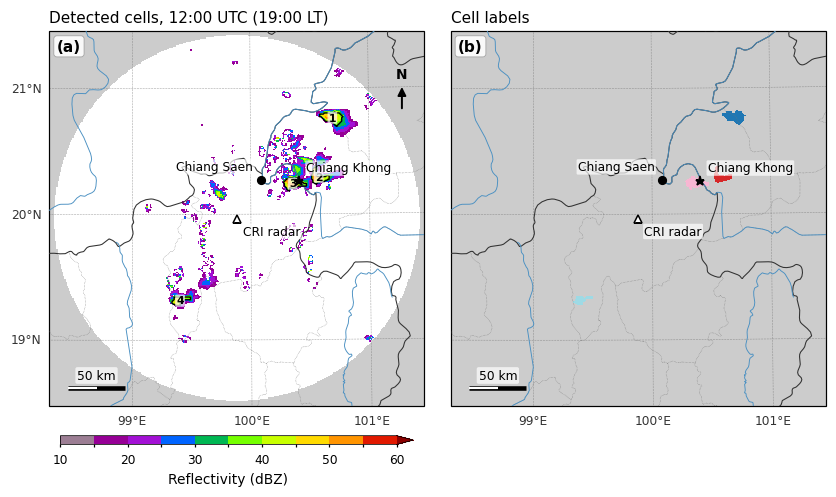

In [4]:
def draw_cells(ax, cell_df, color="k", lw=0.9, ids=True):
    """วาด contour ของเซลล์ (แปลง pixel → UTM ก่อน) และหมายเลข ID"""
    crs = mp.get_crs(meta)
    for _, c in cell_df.iterrows():
        for x, y in tt.contour_xy(c.cont, meta):
            ax.plot(x, y, color=color, lw=lw, transform=crs, zorder=7)
        if ids:
            cx, cy = tt.pixel_to_xy(meta, c.cen_x, c.cen_y)
            ax.text(cx, cy, str(c.ID), transform=crs, fontsize=7, fontweight="bold",
                    ha="center", va="center", zorder=8, clip_on=True,
                    bbox=dict(boxstyle="round,pad=0.1", fc="w", ec="none", alpha=0.7))

fig, axs = mp.map_panels(1, 2, meta, panel_width=3.8, zoom=BOX)
im = mp.radar_map(axs[0], Z[i], meta, units="dBZ", title=f"Detected cells, {mp.tlabel(ts[i])}", zoom=BOX)
draw_cells(axs[0], cells)
lab = np.where(labels > 0, labels, np.nan)
mp.field_map(axs[1], lab, meta, cmap="tab20", title="Cell labels", zoom=BOX,
             gridline_labels=("bottom",))
mp.add_colorbar(fig, im, axs[0], shrink=0.9, label="Reflectivity (dBZ)")
mp.panel_labels(axs)
mp.save_figure(fig, "nb5_fig01_detection")
plt.show()

## 🧭 4. ติดตามเซลล์ตลอดเหตุการณ์ (ข้อมูลทุก 15 นาที)

In [5]:
tic = time.time()
tracks15, cells15, labels15 = tdating.dating(input_video=Z, timelist=ts, mintrack=3,
                                             output_splits_merges=True, **PARAMS)
print(f"พบ {len(tracks15)} tracks (อย่างน้อย 3 ภาพ) ใช้เวลา {time.time()-tic:.0f} s")
summary15 = tt.track_table(tracks15, meta)

# track ที่ผ่านใกล้เชียงของที่สุด
ck_x, ck_y = tt.lonlat_to_xy(meta, *tt.CHIANG_KHONG)
def closest_approach(tr):
    x, y = tt.pixel_to_xy(meta, tr.cen_x.values, tr.cen_y.values)
    d = np.hypot(x - ck_x, y - ck_y) / 1000
    k = int(np.argmin(d))
    return d[k], pd.Timestamp(tr.time.values[k])
summary15["min_dist_CK_km"], summary15["time_closest_utc"] = zip(*[closest_approach(t) for t in tracks15])
summary15.round(1)

พบ 5 tracks (อย่างน้อย 3 ภาพ) ใช้เวลา 16 s


,track_id,start_utc,end_utc,n_frames,lifetime_min,path_km,speed_kmh,direction_to_deg,max_dbz,max_area_km2,min_dist_CK_km,time_closest_utc
0,1,2020-04-23 11:30:00,2020-04-23 13:30:00,9,120.0,89.9,45.0,88.0,55.8,372.0,3.5,2020-04-23 12:15:00
1,2,2020-04-23 11:30:00,2020-04-23 12:00:00,3,30.0,26.9,53.8,63.4,49.0,93.0,148.5,2020-04-23 12:00:00
2,3,2020-04-23 11:45:00,2020-04-23 12:15:00,3,30.0,27.5,54.9,56.9,52.7,163.0,50.2,2020-04-23 11:45:00
3,4,2020-04-23 13:15:00,2020-04-23 14:00:00,4,45.0,38.5,51.4,74.5,49.9,270.0,38.7,2020-04-23 13:15:00
4,5,2020-04-23 13:30:00,2020-04-23 14:00:00,3,30.0,24.2,48.5,73.1,54.4,119.0,3.8,2020-04-23 13:30:00


### แผนที่เส้นทางพายุ (storm tracks) บนพื้นหลัง reflectivity สูงสุดของเหตุการณ์

บันทึกรูปแล้ว: figures/nb5_fig02_tracks_15min.png, figures/nb5_fig02_tracks_15min.pdf


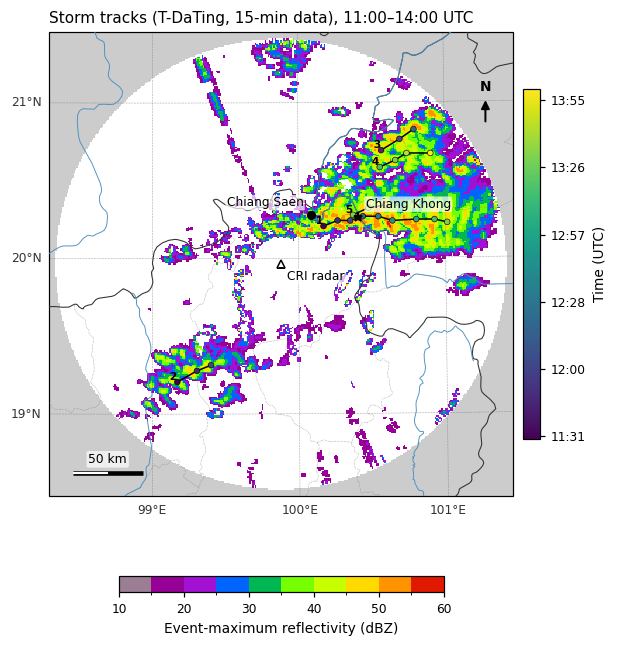

In [6]:
import matplotlib as mpl
def draw_tracks(ax, tracks, cmap="viridis", label=True):
    crs = mp.get_crs(meta)
    t_all = pd.to_datetime(np.concatenate([t.time.values for t in tracks]))
    norm = mpl.colors.Normalize(mdates_num(t_all.min()), mdates_num(t_all.max()))
    for k, tr in enumerate(tracks):
        x, y = tt.pixel_to_xy(meta, tr.cen_x.values, tr.cen_y.values)
        ax.plot(x, y, color="k", lw=1.0, transform=crs, zorder=7)
        sc = ax.scatter(x, y, c=[mdates_num(t) for t in pd.to_datetime(tr.time.values)], cmap=cmap,
                        norm=norm, s=14, edgecolor="k", linewidth=0.4, transform=crs, zorder=8)
        if label:
            ax.text(x[0], y[0], f" {k+1}", transform=crs, fontsize=7, fontweight="bold",
                    ha="right", va="bottom", zorder=9, clip_on=True)
    return sc

import matplotlib.dates as mdates
mdates_num = mdates.date2num
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    Zmax = np.nanmax(Z, axis=0)

fig, axs = mp.map_panels(1, 1, meta, panel_width=5.5, zoom=BOX)
im = mp.radar_map(axs[0], Zmax, meta, units="dBZ", zoom=BOX,
                  title="Storm tracks (T-DaTing, 15-min data), 11:00–14:00 UTC")
sc = draw_tracks(axs[0], tracks15)
cb1 = fig.colorbar(im, ax=axs[0], orientation="horizontal", shrink=0.7, pad=0.03,
                   label="Event-maximum reflectivity (dBZ)")
cb2 = fig.colorbar(sc, ax=axs[0], orientation="vertical", shrink=0.6, pad=0.02, label="Time (UTC)")
cb2.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
mp.save_figure(fig, "nb5_fig02_tracks_15min")
plt.show()

### วิวัฒนาการของเซลล์ตามเวลา (life cycle)

บันทึกรูปแล้ว: figures/nb5_fig03_life_cycle.png, figures/nb5_fig03_life_cycle.pdf


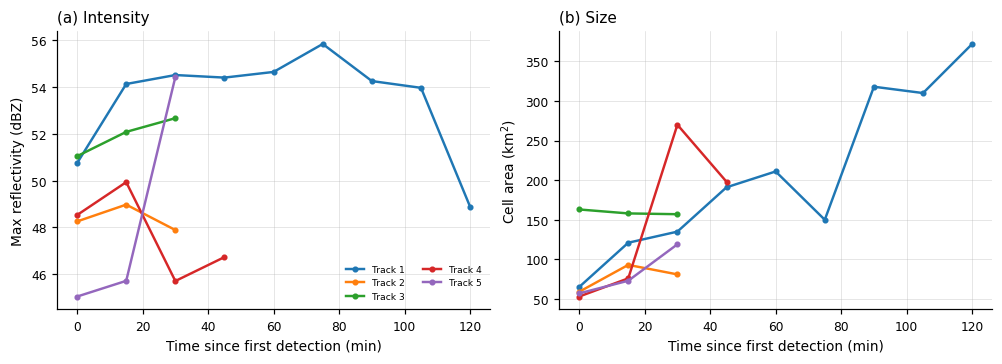

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3.2), layout="constrained")
for k, tr in enumerate(tracks15):
    t = pd.to_datetime(tr.time.values)
    age = (t - t[0]).total_seconds() / 60            # คำนวณจากเวลาจริง (ใช้ได้กับทุกความถี่ข้อมูล)
    axs[0].plot(age, tr.max_ref, "o-", ms=3, label=f"Track {k+1}")
    axs[1].plot(age, tr.area * (meta["xpixelsize"] / 1000) ** 2, "o-", ms=3)
mp.skill_axes(axs[0], xlabel="Time since first detection (min)", ylabel="Max reflectivity (dBZ)",
              title="(a) Intensity")
mp.skill_axes(axs[1], xlabel="Time since first detection (min)", ylabel="Cell area (km$^2$)",
              title="(b) Size")
axs[0].legend(frameon=False, fontsize=6, ncol=2)
mp.save_figure(fig, "nb5_fig03_life_cycle")
plt.show()

## ⏱️ 5. ติดตามด้วยข้อมูลที่ interpolate เป็น 5 นาที
ใช้ `tt.advection_interpolate` (เหมือน NB2) กับ dBZ โดยตรง แล้วรัน T-DaTing อีกครั้ง
> ⚠️ ข้อมูล 5 นาทีนี้ **ไม่ใช่ค่าสังเกตจริง** แต่เป็นการประมาณจาก motion field ภาพที่ interpolate จะไม่มีการเกิด/สลายตัวใหม่ระหว่างภาพ ต้องระบุให้ชัดเมื่อนำไปใช้ในงานวิจัย

In [8]:
tic = time.time()
Z5, ts5, _ = tt.advection_interpolate(Z, meta, n_sub=3, fill_value=0.0)
tracks5, cells5, labels5 = tdating.dating(input_video=Z5, timelist=list(ts5), mintrack=3, **PARAMS)
summary5 = tt.track_table(tracks5, meta)
summary5["min_dist_CK_km"], summary5["time_closest_utc"] = zip(*[closest_approach(t) for t in tracks5])
print(f"5 นาที: {len(ts5)} ภาพ, พบ {len(tracks5)} tracks ({time.time()-tic:.0f} s)")

comp = pd.DataFrame({
    "data": ["15 min (observed)", "5 min (interpolated)"],
    "n_tracks": [len(summary15), len(summary5)],
    "mean_lifetime_min": [summary15.lifetime_min.mean(), summary5.lifetime_min.mean()],
    "max_lifetime_min": [summary15.lifetime_min.max(), summary5.lifetime_min.max()],
    "median_speed_kmh": [summary15.speed_kmh.median(), summary5.speed_kmh.median()],
})
comp.round(1)

5 นาที: 37 ภาพ, พบ 8 tracks (62 s)


,data,n_tracks,mean_lifetime_min,max_lifetime_min,median_speed_kmh
0,15 min (observed),5,51.0,120.0,51.4
1,5 min (interpolated),8,53.8,140.0,45.6


บันทึกรูปแล้ว: figures/nb5_fig04_tracks_15_vs_5min.png, figures/nb5_fig04_tracks_15_vs_5min.pdf


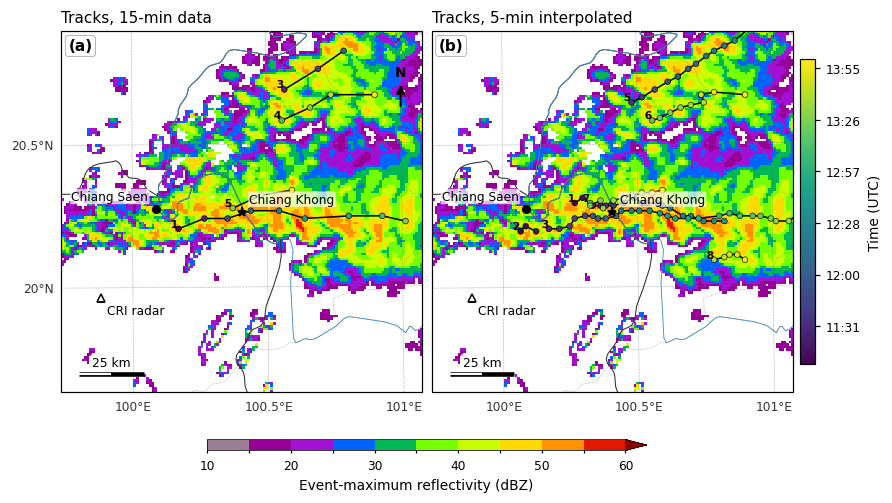

In [9]:
fig, axs = mp.map_panels(1, 2, meta, panel_width=4.0, zoom=CK_BOX)
for j, (trk, ttl) in enumerate([(tracks15, "15-min data"), (tracks5, "5-min interpolated")]):
    im = mp.radar_map(axs[j], Zmax, meta, units="dBZ", zoom=CK_BOX, title=f"Tracks, {ttl}",
                      gridline_labels=("left", "bottom") if j == 0 else ("bottom",), north=(j == 0))
    sc = draw_tracks(axs[j], trk)
mp.add_colorbar(fig, im, axs, label="Event-maximum reflectivity (dBZ)", shrink=0.6)
cb2 = fig.colorbar(sc, ax=list(axs), orientation="vertical", shrink=0.7, pad=0.01, label="Time (UTC)")
cb2.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
mp.panel_labels(axs)
mp.save_figure(fig, "nb5_fig04_tracks_15_vs_5min")
plt.show()

> 🔍 **สังเกต:** ข้อมูล 5 นาทีให้ track ที่ **ยาวและต่อเนื่องกว่า** เพราะเซลล์ซ้อนทับกันมากขึ้นระหว่างภาพ ส่วนข้อมูล 15 นาทีมักได้ track สั้นหลายเส้นจากพายุลูกเดียวกัน ซึ่งทำให้ประเมินอายุพายุต่ำเกินจริง

## 💾 6. ส่งออกเส้นทางพายุเป็น GeoPackage และ CSV
> 🐞 **แก้ bug จาก notebook เดิม:** `cen_x`, `cen_y` และ `cont` ของ T-DaTing เป็น **ตำแหน่ง pixel** ต้องแปลงเป็นพิกัด UTM ด้วย affine transform (`tt.pixel_to_xy`) ก่อนบันทึก มิฉะนั้นจุดจะไปอยู่ใกล้พิกัด (0, 0) นอกประเทศไทย

In [10]:
os.makedirs("output", exist_ok=True)
pts5, lines5 = tt.tracks_to_gdf(tracks5, meta)
pts5.to_file("output/storm_tracks_5min.gpkg", layer="centroids", driver="GPKG")
lines5.to_file("output/storm_tracks_5min.gpkg", layer="tracks", driver="GPKG")
summary5.to_csv("output/storm_track_summary_5min.csv", index=False)
print("CRS:", lines5.crs)
print("ตัวอย่างพิกัด (UTM 47N):", lines5.geometry.iloc[0].coords[0])
print("ไฟล์:", sorted(os.listdir("output")))

CRS: +proj=utm +zone=47 +datum=WGS84 +units=m +no_defs +type=crs
ตัวอย่างพิกัด (UTM 47N): (632291.6913677369, 2244654.0053568287)
ไฟล์: ['storm_track_summary_5min.csv', 'storm_tracks_5min.gpkg']


---
## 🧪 แบบฝึกหัด

### 🧪 แบบฝึกหัด 5.1: ความไวของ minref

รัน T-DaTing กับข้อมูล **5 นาที (Z5)** ด้วย `minref` = **35, 40 และ 45 dBZ** (ปรับ `minmax` = minref + 6 และ `maxref` = max(48, minref + 8)) แล้วสรุปเป็นตาราง: จำนวน track, อายุเฉลี่ย, อายุสูงสุด และพื้นที่เซลล์สูงสุดเฉลี่ย

**คำถาม:** ถ้าต้องการติดตาม "เซลล์ที่อาจให้ลูกเห็บ" ควรใช้ minref เท่าใด? มีข้อแลกเปลี่ยนอย่างไร?

<details>
<summary><b>💡 คำใบ้ (คลิกเพื่อเปิด)</b></summary>

- `p = dict(PARAMS, minref=mr, minmax=mr + 6, maxref=max(48, mr + 8))`
- `trk, _, _ = tdating.dating(input_video=Z5, timelist=list(ts5), mintrack=3, **p)`
- `s = tt.track_table(trk, meta)` แล้วใช้ `s.lifetime_min.mean()`

</details>

In [11]:
# ✍️ แบบฝึกหัด 5.1 — เขียนโค้ดของคุณที่นี่ (ลบ # หน้าบรรทัดแล้วเติมส่วนที่เป็น ...)
# rows = []
# for mr in [35, 40, 45]:
#     p = dict(PARAMS, minref=mr, minmax=mr + 6, maxref=max(48, mr + 8))
#     trk, _, _ = tdating.dating(input_video=Z5, timelist=list(ts5), mintrack=3, **p)
#     s = tt.track_table(trk, meta)
#     rows.append({...})
# pd.DataFrame(rows)

In [12]:
#@title ✅ เฉลยแบบฝึกหัด 5.1 (ลองทำเองก่อน! ดับเบิลคลิกเพื่อดูโค้ด แล้วกด ▶ เพื่อรัน)
rows = []
for mr in [35, 40, 45]:
    p = dict(PARAMS, minref=mr, minmax=mr + 6, maxref=max(48, mr + 8))
    trk, _, _ = tdating.dating(input_video=Z5, timelist=list(ts5), mintrack=3, **p)
    s = tt.track_table(trk, meta)
    rows.append({"minref (dBZ)": mr, "n_tracks": len(s),
                 "mean_lifetime_min": s.lifetime_min.mean() if len(s) else np.nan,
                 "max_lifetime_min": s.lifetime_min.max() if len(s) else np.nan,
                 "mean_max_area_km2": s.max_area_km2.mean() if len(s) else np.nan})
pd.DataFrame(rows).round(1)

,minref (dBZ),n_tracks,mean_lifetime_min,max_lifetime_min,mean_max_area_km2
0,35,8,53.8,140.0,179.1
1,40,4,45.0,120.0,123.0
2,45,0,NaN,NaN,NaN


### 🧪 แบบฝึกหัด 5.2: พายุลูกเห็บเข้าเชียงของกี่โมง?

จากตาราง `summary5` เลือก track ที่ผ่านใกล้เชียงของที่สุด (`min_dist_CK_km` น้อยที่สุด) แล้ว
1. รายงานเวลาที่เข้าใกล้ที่สุดทั้ง **UTC และเวลาไทย**, ระยะห่าง, ความเร็ว, ทิศทาง และ dBZ สูงสุดของ track
2. ทำแผนที่ซูมรอบเชียงของแสดงเฉพาะ track นั้น พร้อม contour ของเซลล์ ณ เวลาที่เข้าใกล้ที่สุด

**คำถาม:** ถ้าระบบเตือนภัยติดตามพายุลูกนี้ได้ตั้งแต่ตรวจพบครั้งแรก จะมีเวลาเตือนล่วงหน้า (lead time) กี่นาทีก่อนพายุถึงเชียงของ?

<details>
<summary><b>💡 คำใบ้ (คลิกเพื่อเปิด)</b></summary>

- `k = summary5.min_dist_CK_km.idxmin()` แล้ว `tr = tracks5[k]`
- เวลาไทย: `t + pd.Timedelta(hours=7)`
- contour ณ เวลาที่ใกล้ที่สุด: แถวของ `tr` ที่ `time == summary5.time_closest_utc[k]` แล้วเรียก `draw_cells(ax, แถวนั้น)`
- เวลาเตือนล่วงหน้า = `time_closest_utc - start_utc`

</details>

In [13]:
# ✍️ แบบฝึกหัด 5.2 — เขียนโค้ดของคุณที่นี่ (ลบ # หน้าบรรทัดแล้วเติมส่วนที่เป็น ...)
# k = summary5.min_dist_CK_km.idxmin()
# tr = tracks5[k]
# row = summary5.loc[k]
# print(row)
# fig, axs = mp.map_panels(1, 1, meta, panel_width=4.5, zoom=CK_BOX)
# ...

Track 3: เริ่ม 11:30 UTC, สิ้นสุด 13:50 UTC (อายุ 140 นาที)
เข้าใกล้เชียงของที่สุด 12:10 UTC = 19:10 น. เวลาไทย, ห่าง 2.2 km
ความเร็ว 47 km/h, ทิศที่ไป 86°, dBZ สูงสุด 55.8
เวลาเตือนล่วงหน้าตั้งแต่ตรวจพบครั้งแรก: 40 นาที
บันทึกรูปแล้ว: figures/nb5_ex52_chiang_khong_track.png, figures/nb5_ex52_chiang_khong_track.pdf


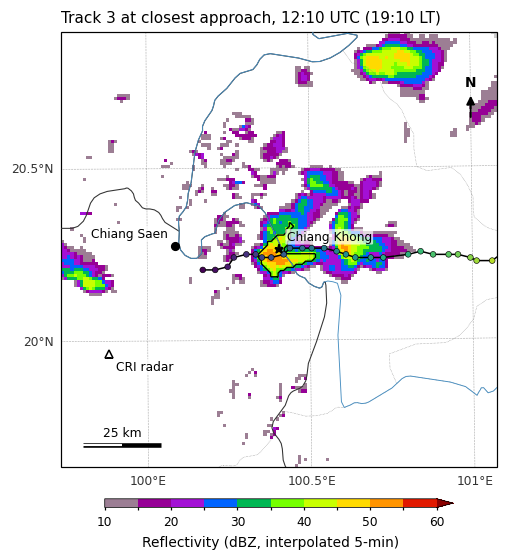

In [14]:
#@title ✅ เฉลยแบบฝึกหัด 5.2 (ลองทำเองก่อน! ดับเบิลคลิกเพื่อดูโค้ด แล้วกด ▶ เพื่อรัน)
k = int(summary5.min_dist_CK_km.idxmin())
tr, row = tracks5[k], summary5.loc[k]
t_cl = pd.Timestamp(row.time_closest_utc)
print(f"Track {row.track_id}: เริ่ม {row.start_utc:%H:%M} UTC, สิ้นสุด {row.end_utc:%H:%M} UTC (อายุ {row.lifetime_min:.0f} นาที)")
print(f"เข้าใกล้เชียงของที่สุด {t_cl:%H:%M} UTC = {t_cl + pd.Timedelta(hours=7):%H:%M} น. เวลาไทย, ห่าง {row.min_dist_CK_km:.1f} km")
print(f"ความเร็ว {row.speed_kmh:.0f} km/h, ทิศที่ไป {row.direction_to_deg:.0f}°, dBZ สูงสุด {row.max_dbz:.1f}")
print(f"เวลาเตือนล่วงหน้าตั้งแต่ตรวจพบครั้งแรก: {(t_cl - row.start_utc).total_seconds()/60:.0f} นาที")

fig, axs = mp.map_panels(1, 1, meta, panel_width=4.5, zoom=CK_BOX)
i5 = int(np.argmin([abs((pd.Timestamp(t) - t_cl).total_seconds()) for t in ts5]))
im = mp.radar_map(axs[0], Z5[i5], meta, units="dBZ", zoom=CK_BOX,
                  title=f"Track {row.track_id} at closest approach, {mp.tlabel(t_cl.to_pydatetime())}")
draw_tracks(axs[0], [tr], label=False)
draw_cells(axs[0], tr[pd.to_datetime(tr.time.values) == t_cl], color="k", ids=False)
mp.add_colorbar(fig, im, axs, shrink=0.8, label="Reflectivity (dBZ, interpolated 5-min)")
mp.save_figure(fig, "nb5_ex52_chiang_khong_track")
plt.show()

### 🧪 แบบฝึกหัด 5.3: (เสริม) Cell-based nowcast: เซลล์จะไปอยู่ที่ไหนใน 30 นาที?

นำ contour ของเซลล์ทั้งหมดที่ตรวจพบ ณ **11:45 UTC** (ข้อมูล 15 นาที, `cells15[3]`) มา **เลื่อนไปข้างหน้า 30 นาที** ด้วยความเร็วจาก motion field (LK) ที่ตำแหน่ง centroid ของแต่ละเซลล์ แล้ววาดทับบนภาพจริง ณ 12:15 UTC

**คำถาม:** การพยากรณ์แบบ object-based มีข้อดีอะไรสำหรับการสื่อสารคำเตือน? และมีข้อจำกัดอะไรเมื่อเซลล์เปลี่ยนขนาดหรือแยกตัว?

<details>
<summary><b>💡 คำใบ้ (คลิกเพื่อเปิด)</b></summary>

- motion field จาก dBZ: `V = pysteps.motion.get_method("LK")(Z[1:4] ที่แทน NaN ด้วย 0, verbose=False)` (หน่วย pixel ต่อ 15 นาที)
- ที่ centroid `(cen_y, cen_x)` ของเซลล์: `u = V[0, cy, cx]`, `v = V[1, cy, cx]`
- เลื่อน 30 นาที = 2 time steps: contour ใหม่ = `c[:, 1] + 2*u` (col) และ `c[:, 0] + 2*v` (row)

</details>

In [15]:
# ✍️ แบบฝึกหัด 5.3 — เขียนโค้ดของคุณที่นี่ (ลบ # หน้าบรรทัดแล้วเติมส่วนที่เป็น ...)
# from pysteps import motion
# V = motion.get_method("LK")(np.nan_to_num(Z[1:4]), verbose=False)
# shifted = []
# for _, c in cells15[3].iterrows():
#     u, v = V[0, int(c.cen_y), int(c.cen_x)], V[1, int(c.cen_y), int(c.cen_x)]
#     ...

In [ ]:
#@title ✅ เฉลยแบบฝึกหัด 5.3 (ลองทำเองก่อน! ดับเบิลคลิกเพื่อดูโค้ด แล้วกด ▶ เพื่อรัน)
from pysteps import motion
V = motion.get_method("LK")(np.nan_to_num(Z[1:4]), verbose=False)
crs = mp.get_crs(meta)
fig, axs = mp.map_panels(1, 1, meta, panel_width=4.8, zoom=CK_BOX)
im = mp.radar_map(axs[0], Z[5], meta, units="dBZ", zoom=CK_BOX,
                  title=f"Observed {mp.tlabel(ts[5])} + cells from {ts[3]:%H:%M} shifted +30 min")
for _, c in cells15[3].iterrows():
    u, v = V[0, int(c.cen_y), int(c.cen_x)], V[1, int(c.cen_y), int(c.cen_x)]
    for cont in c.cont:
        cont = np.asarray(cont)
        x0, y0 = tt.pixel_to_xy(meta, cont[:, 1], cont[:, 0])
        x1, y1 = tt.pixel_to_xy(meta, cont[:, 1] + 2 * u, cont[:, 0] + 2 * v)
        axs[0].plot(x0, y0, color="0.4", lw=0.7, ls=":", transform=crs, zorder=7)
        axs[0].plot(x1, y1, color="k", lw=1.1, transform=crs, zorder=7)
draw_cells(axs[0], cells15[5], color="#00a5c8", lw=1.4, ids=False)
from matplotlib.lines import Line2D
axs[0].legend(handles=[Line2D([], [], color="0.4", ls=":", label=f"Cells at {ts[3]:%H:%M}"),
                       Line2D([], [], color="k", label="Forecast +30 min"),
                       Line2D([], [], color="#00a5c8", lw=1.4, label=f"Observed cells {ts[5]:%H:%M}")],
              loc="lower right", fontsize=7, framealpha=0.85)
mp.add_colorbar(fig, im, axs, shrink=0.8, label="Reflectivity (dBZ)")
mp.save_figure(fig, "nb5_ex53_cell_nowcast")
plt.show()

---
## 📝 สรุป
- T-DaTing มองพายุเป็น **วัตถุ** ตรวจจับด้วย multi-threshold แล้วติดตามด้วย optical flow + overlap matching
- พารามิเตอร์มีหน่วยเป็น **pixel และ time step** ต้องปรับให้เหมาะกับความละเอียดของข้อมูล
- ข้อมูลทุก 15 นาทีทำให้ track ขาดตอน การ interpolate เป็น 5 นาทีช่วยให้ track ต่อเนื่องขึ้น (แต่ต้องระบุข้อจำกัด)
- ผลลัพธ์ส่งออกเป็น **GeoPackage** ที่มีพิกัด UTM ถูกต้อง นำไปซ้อนทับกับข้อมูลความเสียหาย/รายงานลูกเห็บใน GIS ได้

### ❓ คำถามชวนคิด / โครงงานต่อยอด
1. นำ GeoPackage ไปซ้อนทับกับขอบเขตตำบลใน QGIS แล้วระบุตำบลที่พายุผ่าน เทียบกับรายงานความเสียหาย (เช่น ต.สถาน, ต.เวียง อ.เชียงของ)
2. ถ้ามีข้อมูลเรดาร์หลายระดับความสูง (volume scan) จะเพิ่มตัวชี้วัดลูกเห็บอะไรได้บ้าง (echo top, VIL, POH)?
3. ออกแบบระบบเตือนภัยลูกเห็บอย่างง่ายสำหรับภาคเหนือ โดยใช้ T-DaTing + STEPS จากหลักสูตรนี้

### 🎓 จบหลักสูตร!
นิสิตได้ทำครบกระบวนการกับข้อมูลจริงของกรมอุตุนิยมวิทยา: **QC → Z–R → motion → deterministic → probabilistic → object-based tracking**

### 📚 เอกสารอ้างอิง
- Feldmann, M., Germann, U., Gabella, M., & Berne, A. (2021). A characterisation of Alpine mesocyclone occurrence. *Weather Clim. Dynam.*, 2, 1225–1244. (T-DaTing ใน pysteps)
- Hering, A. M., Morel, C., Galli, G., Sénési, S., Ambrosetti, P., & Boscacci, M. (2004). Nowcasting thunderstorms in the Alpine region using a radar based adaptive thresholding scheme. *Proc. ERAD 2004*, 206–211. (TRT)
- Dixon, M., & Wiener, G. (1993). TITAN: Thunderstorm Identification, Tracking, Analysis, and Nowcasting. *J. Atmos. Oceanic Technol.*, 10, 785–797.
- pysteps example: [Thunderstorm detection and tracking – T-DaTing](https://pysteps.readthedocs.io/en/stable/auto_examples/thunderstorm_detection_and_tracking.html)